In [1]:
%matplotlib inline

import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE" # tells OpenMP to not complain if it notices that two copies of OpenMP are loaded.

from IPython.display import Video
from IPython.display import Audio as play_audio
from torchvision.utils import make_grid
from torchcodec.encoders import VideoEncoder

def play_video(encoded_bytes):
    return Video(data=encoded_bytes.numpy().tobytes(),
                embed=True, width=640, height=360, mimetype="video/mp4")

import matplotlib.pyplot as plt

import sys
sys.path.append('../../../')

In [4]:
import os
import time
import warnings
import datetime
from pathlib import Path
from typing import Any, Callable, Optional, Union, cast

import torch
from torchcodec.decoders import VideoDecoder

import numpy as np

%load_ext autoreload
%autoreload 2

from computer_vision.torch_video.parameter_parser import parser


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
data_dirpath=Path('D:/data/UCF101')
root=data_dirpath/'UCF-101'
annotation_path=data_dirpath/'UCF101TrainTestSplits-RecognitionTask'
output_dirpath=Path('D:/results/ucf101/train')
metadata_path=data_dirpath/'metadata.pt'
class_id_path=annotation_path/"classInd.txt"
allowed_time=10/60

arguments= f"""-d {root} -a {annotation_path} -m {metadata_path} -o {output_dirpath} -c {class_id_path}
--data-fold 1 --frame-rate 8 --clip-duration 2 --step-duration 1.7 
--device cpu --use-cutmix-mixup --time {allowed_time} --n-batches 4 --epochs 2
"""
args=parser.parse_args(arguments.split())


heights={240: 3779, 226: 4}, sum(list(heights.values()))=3783, len(samples)=3783
widths={320: 3779, 400: 4}, sum(list(widths.values()))=3783, len(widths)=2
len(duration_seconds)=3783, len(num_frames_from_content)=3783, len(average_fps)=3783


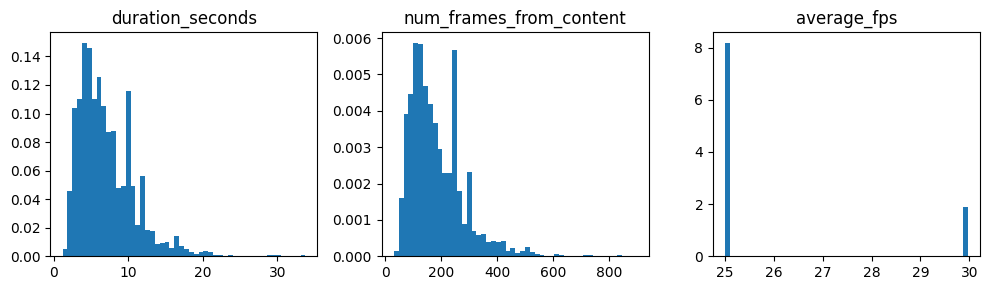

In [11]:
ann_path=Path(args.annotation_path)/"testlist01.txt"
with open(ann_path, 'r') as f: samples= f.read().strip().split('\n')

heights, widths=dict(),dict()
duration_seconds, num_frames_from_content, average_fps=[],[],[]
for sample in samples:
    sample_path=Path(args.data_path)/sample
    assert sample_path.is_file()
    decoder=VideoDecoder(sample_path)
    if decoder.metadata.height not in heights: heights[decoder.metadata.height]=0
    if decoder.metadata.width not in widths: widths[decoder.metadata.width]=0
    heights[decoder.metadata.height]+=1
    widths[decoder.metadata.width]+=1

    duration_seconds.append(decoder.metadata.duration_seconds)
    num_frames_from_content.append(decoder.metadata.num_frames_from_content)
    average_fps.append(decoder.metadata.average_fps)
    
print(f"{heights=}, {sum(list(heights.values()))=}, {len(samples)=}")
print(f"{widths=}, {sum(list(widths.values()))=}, {len(widths)=}")
print(f"{len(duration_seconds)=}, {len(num_frames_from_content)=}, {len(average_fps)=}")

_, ax=plt.subplots(1,3,figsize=(10,3))
for i, (n, x) in enumerate(zip(['duration_seconds', 'num_frames_from_content', 'average_fps'],
                       [duration_seconds, num_frames_from_content, average_fps])):
    ax[i].hist(x, bins=50, density=True, histtype='bar')
    ax[i].set_title(n)
plt.tight_layout()

heights={240: 9537}, sum(list(heights.values()))=9537, len(samples)=9537
widths={320: 9537}, sum(list(widths.values()))=9537, len(widths)=1
len(duration_seconds)=9537, len(num_frames_from_content)=9537, len(average_fps)=9537


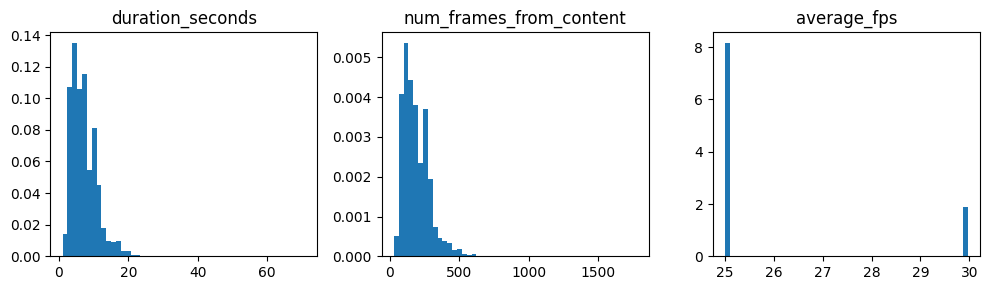

In [12]:
ann_path=Path(args.annotation_path)/"trainlist01.txt"
with open(ann_path, 'r') as f: samples= f.read().strip().split('\n')

heights, widths=dict(),dict()
duration_seconds, num_frames_from_content, average_fps=[],[],[]
for sample in samples:
    sample_path=Path(args.data_path)/sample.split(' ')[0]
    assert sample_path.is_file()
    decoder=VideoDecoder(sample_path)
    if decoder.metadata.height not in heights: heights[decoder.metadata.height]=0
    if decoder.metadata.width not in widths: widths[decoder.metadata.width]=0
    heights[decoder.metadata.height]+=1
    widths[decoder.metadata.width]+=1

    duration_seconds.append(decoder.metadata.duration_seconds)
    num_frames_from_content.append(decoder.metadata.num_frames_from_content)
    average_fps.append(decoder.metadata.average_fps)
    
print(f"{heights=}, {sum(list(heights.values()))=}, {len(samples)=}")
print(f"{widths=}, {sum(list(widths.values()))=}, {len(widths)=}")
print(f"{len(duration_seconds)=}, {len(num_frames_from_content)=}, {len(average_fps)=}")

_, ax=plt.subplots(1,3,figsize=(10,3))
for i, (n, x) in enumerate(zip(['duration_seconds', 'num_frames_from_content', 'average_fps'],
                       [duration_seconds, num_frames_from_content, average_fps])):
    ax[i].hist(x, bins=50, density=True, histtype='bar')
    ax[i].set_title(n)
plt.tight_layout()